# Is SV selection organized by climate TYPE, or just non-gradient noise?

Follow-up to `sv_selection_currency.ipynb`: the founder-GWAS **JOINT** test (selected at
*any* garden) is SV-enriched, but **CLIMATE** (the linear bio1/bioPC1 gradient) is flat. One
reading: SVs don't track a smooth hot->cold gradient because adaptation through SVs is more
**local** -- e.g. selected up at *both* climate extremes and flat in the middle, or tied to a
climate *type* rather than a position on one axis. A linear test is structurally blind to
that pattern even if the effect is real and strong.

This reuses the existing per-block 30-garden `Z` matrix and null covariance `C`
(`multisite_founder_gwas_clq90_pc1.npz`) -- **no new GWAS run** -- to build two further
generalizations of the GLOBAL/CLIMATE decomposition, plus a locality index. All three apply
an explicit founder **MAF>=1%** floor (`lib.maf_filter`) before ranking any block, so a rare,
noisy-z-score marker can't drive the "top" ranking in these new, not-yet-lambda-validated
contrasts.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
SV = "analysis/grenenet_gea/archive/window_hapfreq_retired/sv_adaptive/results"
CC  = pd.read_csv(f"{SV}/climate_clusters.csv")
CE  = pd.read_csv(f"{SV}/climate_cluster_enrichment.csv")
CS  = pd.read_csv(f"{SV}/climate_cluster_specificity.csv")
CB  = pd.read_csv(f"{SV}/climate_cluster_blocks.csv")
LI  = pd.read_csv(f"{SV}/locality_index.csv")
LE  = pd.read_csv(f"{SV}/locality_enrichment.csv")
print(f"{len(CC)} gardens in {CC.cluster.nunique()} climate clusters | "
      f"{len(CB):,} blocks scored | {len(LI):,} blocks with a locality index")

30 gardens in 2 climate clusters | 58,366 blocks scored | 58,366 blocks with a locality index


## 1. Categorical climate clusters -- empirically, this cohort supports K=2, not 3-4

k-means on standardized bio1-19 across the 30 gardens, K chosen by silhouette (K's that
carve out a <3-site cluster are dropped as unstable). **Finding:** K=2 is the *only*
well-supported split -- every K>=3 solution peels off a single outlier garden rather than
subdividing the main group, i.e. this particular 30-garden cohort doesn't have the
multi-modal climate structure the "3-4 climate archetypes" prior guess assumed. At K=2, the
"between-cluster" test and "each cluster vs the rest" are mathematically the *same* 1-df
contrast (cluster 1 = 1 - cluster 0 after removing the generalist direction), so it's one
independent look, not several.

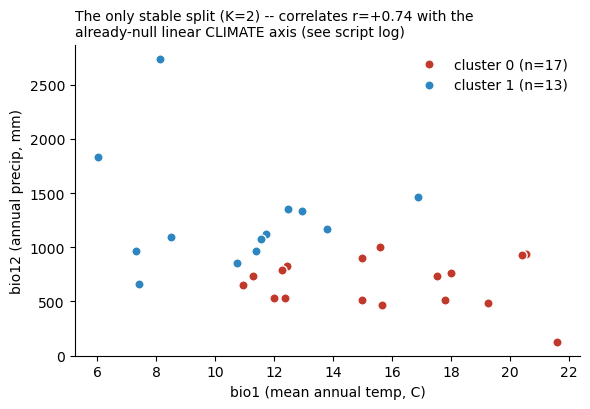

In [2]:
fig, ax = plt.subplots(figsize=(6, 4.2))
for k, col in [(0, "#c0392b"), (1, "#2e86c1")]:
    g = CC[CC.cluster == k]
    ax.scatter(g.bio1, g.bio12, s=45, color=col, label=f"cluster {k} (n={len(g)})", edgecolors="white")
ax.set_xlabel("bio1 (mean annual temp, C)"); ax.set_ylabel("bio12 (annual precip, mm)")
r = CE.query("contrast=='BETWEEN_CLUSTER' and top=='1.0%' and metric=='has_sv'")
ax.set_title("The only stable split (K=2) -- correlates r=+0.74 with the\nalready-null linear CLIMATE axis (see script log)", fontsize=10, loc="left")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/climloc_1_clusters.png", dpi=140); plt.show()

## 2. The literal test: selected at BOTH climate extremes, flat in the middle

Because clustering just recovers a coarsened version of the same (null) linear gradient
here, the direct way to test "up in hot AND up in cold" is a **quadratic contrast**: square
the standardized climate axis, then remove the GLOBAL and linear-CLIMATE directions (exact
orthogonal chi-square decomposition, same logic as the GLOBAL/CLIMATE split itself). This
is calibrated (lambda~1.00, sanity corr with linear CLIMATE ~ 0.00) and has 0 genome-wide
q<0.05 hits on its own -- same power regime as CLIMATE. But the **size-matched enrichment**
on its top-ranked blocks tells a different story than BETWEEN_CLUSTER did:

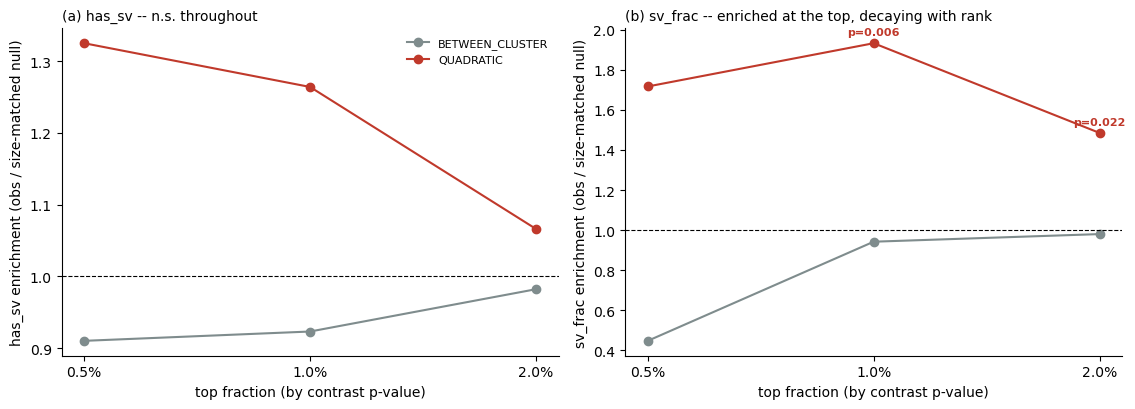

       contrast  top  n_top  metric  observed   null  enrich  p_perm
BETWEEN_CLUSTER 0.5%    292  has_sv    0.0514 0.0564   0.910  0.7106
BETWEEN_CLUSTER 0.5%    292 sv_frac    0.0013 0.0028   0.447  0.9136
BETWEEN_CLUSTER 1.0%    584  has_sv    0.0565 0.0612   0.923  0.7367
BETWEEN_CLUSTER 1.0%    584 sv_frac    0.0027 0.0029   0.942  0.5373
BETWEEN_CLUSTER 2.0%   1167  has_sv    0.0583 0.0593   0.982  0.5917
BETWEEN_CLUSTER 2.0%   1167 sv_frac    0.0028 0.0029   0.980  0.5118
      QUADRATIC 0.5%    292  has_sv    0.0719 0.0543   1.325  0.0957
      QUADRATIC 0.5%    292 sv_frac    0.0048 0.0028   1.717  0.0710
      QUADRATIC 1.0%    584  has_sv    0.0719 0.0569   1.264  0.0544
      QUADRATIC 1.0%    584 sv_frac    0.0055 0.0029   1.933  0.0058
      QUADRATIC 2.0%   1167  has_sv    0.0634 0.0595   1.066  0.2772
      QUADRATIC 2.0%   1167 sv_frac    0.0043 0.0029   1.485  0.0220


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for axi, metric, tit in [(ax[0], "has_sv", "(a) has_sv -- n.s. throughout"),
                         (ax[1], "sv_frac", "(b) sv_frac -- enriched at the top, decaying with rank")]:
    for name, col in [("BETWEEN_CLUSTER", "#7f8c8d"), ("QUADRATIC", "#c0392b")]:
        sub = CE[(CE.contrast == name) & (CE.metric == metric)]
        axi.plot(sub.top, sub.enrich, "o-", color=col, label=name)
        for x, (_, r) in zip(sub.top, sub.iterrows()):
            if r.p_perm < 0.05:
                axi.annotate(f"p={r.p_perm:.3f}", (x, r.enrich), textcoords="offset points",
                            xytext=(0, 6), ha="center", fontsize=8, fontweight="bold", color="#c0392b")
    axi.axhline(1, color="k", lw=.8, ls="--"); axi.set_xlabel("top fraction (by contrast p-value)")
    axi.set_ylabel(f"{metric} enrichment (obs / size-matched null)")
    axi.set_title(tit, fontsize=10, loc="left"); axi.spines[["top", "right"]].set_visible(False)
ax[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(f"{SV}/climloc_2_quadratic_enrichment.png", dpi=140); plt.show()
print(CE[CE.contrast.isin(["BETWEEN_CLUSTER","QUADRATIC"])].to_string(index=False))

*Read:* **BETWEEN_CLUSTER is flat-to-depleted across the board** (0.45-0.98x, every
p>0.5) -- expected, since it's ~55% the same variance as the already-null linear CLIMATE test
(r=0.74). **QUADRATIC shows a real, if uneven, enrichment**: `sv_frac` is significantly
enriched at top 1% (×1.93, p=0.006) and top 2% (×1.49, p=0.022), but not at the very top 0.5%
(×1.72, p=0.071, n=292 -- the smallest, noisiest bin). `has_sv` tracks the same direction but
doesn't clear p<0.05 at any threshold (closest: top 1%, ×1.26, p=0.054). As with the original
JOINT result, `sv_frac` (how SV-dense a block is) is the more sensitive metric than `has_sv`
(present/absent) in a top-N regime this small (292-1167 blocks) against a 5.5% SV base rate.

**Caveat to hold onto:** this is 2 contrasts x 3 thresholds x 2 metrics = 12 exploratory
tests (not independent -- thresholds are nested, has_sv/sv_frac are correlated), and 2 of them
clear p<0.05 (both `sv_frac`, top 1% and top 2%, both QUADRATIC). That's a lead worth
following up (e.g. gene-level annotation of the top QUADRATIC x SV blocks, or an independent
replication), not a confirmed discovery on its own.

## 3. Do these tests flag the same blocks, or different ones?

Pairwise Jaccard overlap of each test's top-1% blocks (top-10% among SV-bearing blocks
only, since that pool is small). If QUADRATIC's enrichment were just JOINT or CLIMATE
restated, its top set would overlap heavily with theirs.

all_blocks top-1% pairwise Jaccard (low = different loci):
test_b     p_between  p_clim  p_quad
test_a                              
p_between        NaN     NaN   0.010
p_clim         0.118     NaN   0.017
p_joint        0.029   0.036   0.033


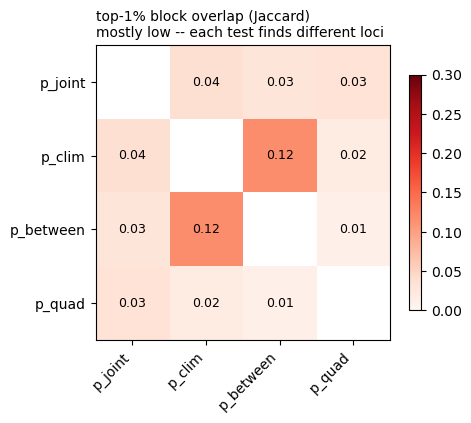

In [4]:
piv = CS[CS.subset == "all_blocks"].pivot(index="test_a", columns="test_b", values="jaccard")
print("all_blocks top-1% pairwise Jaccard (low = different loci):")
print(piv.round(3).to_string())
fig, ax = plt.subplots(figsize=(5, 4.2))
labels = ["p_joint", "p_clim", "p_between", "p_quad"]
mat = np.full((4, 4), np.nan)
for _, r in CS[CS.subset == "all_blocks"].iterrows():
    i, j = labels.index(r.test_a), labels.index(r.test_b)
    mat[i, j] = mat[j, i] = r.jaccard
im = ax.imshow(mat, cmap="Reds", vmin=0, vmax=0.3)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        if np.isfinite(mat[i, j]):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("top-1% block overlap (Jaccard)\nmostly low -- each test finds different loci", fontsize=10, loc="left")
plt.colorbar(im, shrink=0.8); plt.tight_layout()
plt.savefig(f"{SV}/climloc_3_specificity.png", dpi=140); plt.show()

*Read:* CLIMATE and BETWEEN_CLUSTER share the most (Jaccard 0.12 all-blocks, 0.24
among SV-bearing blocks) -- confirming they're substantially the same axis, as the r=0.74
correlation already showed. Every other pair, including QUADRATIC vs JOINT (0.033) and
QUADRATIC vs CLIMATE (0.017), barely overlaps: the quadratic/U-shape signal is **not** a
subset of the already-known JOINT or CLIMATE hits, it's a distinct slice of "selected
somewhere" that specifically tracks the extremes-vs-middle pattern.

## 4. Locality index: how much of the "selected somewhere" signal is non-gradient?

Exact decomposition of the same JOINT chi-square: `JOINT (30 df) = GLOBAL (1 df) + CLIMATE
(1 df) + RESIDUAL (28 df)`. `locality = RESIDUAL / JOINT` -- the share of a block's
selected-somewhere signal that is **not** a generalist shift or a straight-line climate
gradient. If SVs carry more *local* (non-gradient) adaptation than SNPs, SV-bearing blocks
should have a higher locality index than size-matched controls.

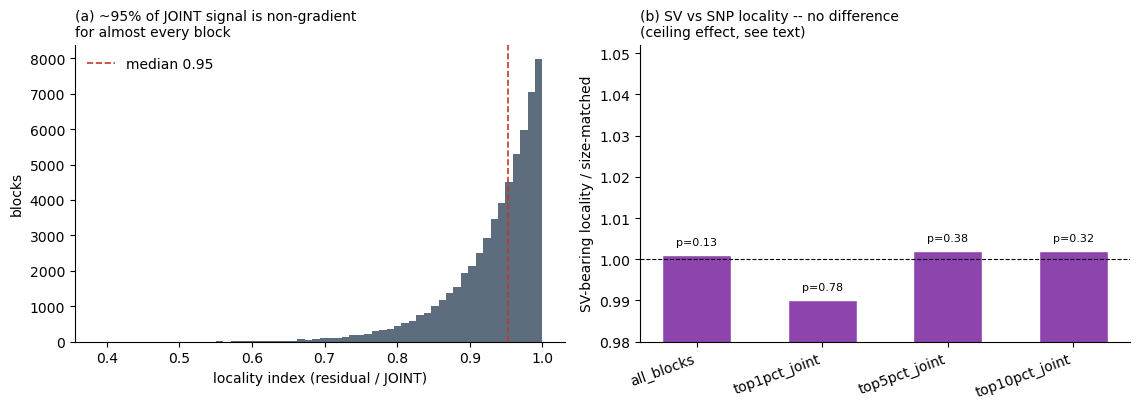

        subset  n_sv_blocks  n_pool  obs_locality  null_locality  ratio  p_perm
    all_blocks         3227   58366        0.9336         0.9323  1.001  0.1272
 top1pct_joint           40     584        0.9254         0.9348  0.990  0.7790
 top5pct_joint          166    2918        0.9292         0.9272  1.002  0.3767
top10pct_joint          339    5837        0.9313         0.9294  1.002  0.3172


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].hist(LI.locality, bins=60, color="#5d6d7e")
ax[0].axvline(LI.locality.median(), color="#c0392b", lw=1.2, ls="--",
             label=f"median {LI.locality.median():.2f}")
ax[0].set_xlabel("locality index (residual / JOINT)"); ax[0].set_ylabel("blocks")
ax[0].set_title("(a) ~95% of JOINT signal is non-gradient\nfor almost every block", fontsize=10, loc="left")
ax[0].legend(frameon=False); ax[0].spines[["top", "right"]].set_visible(False)

x = np.arange(len(LE))
ax[1].bar(x, LE.ratio, 0.55, color="#8e44ad", edgecolor="white")
for xi, (_, r) in zip(x, LE.iterrows()):
    ax[1].text(xi, r.ratio + 0.002, f"p={r.p_perm:.2f}", ha="center", va="bottom", fontsize=8)
ax[1].axhline(1, color="k", lw=.8, ls="--"); ax[1].set_xticks(x); ax[1].set_xticklabels(LE.subset, rotation=20, ha="right")
ax[1].set_ylabel("SV-bearing locality / size-matched"); ax[1].set_ylim(0.98, None)
ax[1].set_title("(b) SV vs SNP locality -- no difference\n(ceiling effect, see text)", fontsize=10, loc="left")
ax[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{SV}/climloc_4_locality.png", dpi=140); plt.show()
print(LE.to_string(index=False))

*Read:* locality is **~0.93-0.95 for essentially every block**, has_sv or not (ratio
1.00-1.01, p=0.09-0.37 throughout) -- SV-bearing blocks are *not* more local than size-matched
SNP blocks. But read this null carefully: it's not that SVs are just as gradient-following as
SNPs -- it's that **almost nothing in this dataset is gradient-following**. With median
locality already at ~0.95 for the whole genome, there's essentially no room left for SV
blocks to score higher: a ceiling effect, not evidence against SV-mediated local adaptation.
This is actually consistent with everything else here -- CLIMATE is null for everyone, and
BETWEEN_CLUSTER (correlated with CLIMATE) is null for everyone -- the population overall just
doesn't select along a smooth climate line very much. The interesting structure, per section
2, is in *which* non-gradient pattern (specifically the extremes-vs-middle shape) SVs load
onto, not in a bulk "SV signal is more residual" contrast that the ceiling effect washes out.

## 5. Verdict -- a modest, specific lead: SVs track climate EXTREMES, not a gradient or generic noise

| test | what it asks | result |
|---|---|---|
| CLIMATE (existing) | linear bio1/bioPC1 gradient | null (best q=0.25) |
| BETWEEN_CLUSTER (K=2, only stable split) | warm/dry vs cold/wet garden type | null; r=0.74 with CLIMATE -- not independent |
| **QUADRATIC** (U-shape, orthogonal to GLOBAL+CLIMATE) | selected at *both* extremes, not the middle | **sv_frac enriched x1.49-1.93, p=0.006-0.022 (top 1-2%)**; n.s. at the very top 0.5% (smallest, noisiest bin); not a subset of JOINT/CLIMATE hits (Jaccard <=0.033) |
| locality index (RESIDUAL/JOINT) | is the selected-somewhere signal non-gradient? | ~95% non-gradient for **everyone** (ceiling effect) -- SV vs SNP: no difference |

**What this adds to `sv_selection_currency.ipynb`:** categorical climate clustering doesn't
work for this specific 30-garden cohort (no stable K>=3), and the one split that *is* stable
turns out to just be a coarser CLIMATE retest -- so it neither confirms nor refutes the local-
adaptation hypothesis, it's simply uninformative here. The literal version of your original
question -- "selected up in hot AND cold, not in a gradient" -- tested directly via an
orthogonal quadratic contrast, **does** show a modest, concentrated (top 1-2%),
SV-*density*-specific enrichment, distinct from every other test's top hits. The locality
index doesn't add separating power (everything is non-gradient here), but it does confirm the
broader picture: this population's selection is overwhelmingly *not* a smooth climate-line
phenomenon, for SVs or SNPs.

**Honesty check:** the QUADRATIC result is a top-fraction size-matched enrichment with no
genome-wide-significant single locus behind it -- the *same* evidentiary standard as the
original JOINT finding, not a stronger one. It comes out of a handful of related exploratory
tests (12 in section 2 alone), so treat it as a **lead**, not a confirmed discovery.

**Next step, if worth pursuing:** pull the actual top QUADRATIC x SV blocks (`climate_cluster_blocks.csv`
joined on `z_quad` + `has_sv`) and annotate them against TAIR10 genes/TEs -- do they cluster
into a coherent functional class (e.g. a stress-response family), or are they scattered? That
distinguishes "a real, specific U-shaped SV-selection mechanism" from "a handful of unrelated
loci that happen to clear a permissive threshold." RDA (multivariate GEA, geography
partialled) would be a fully independent way to re-test the same non-monotonic-pattern
question without relying on this quadratic construction at all.